# Samurai Proof Server Stress Test Visualization

This notebook visualizes the results of the `proofc` stress test.

By default, it will find and load the most recent `stress_*.csv` file in the `benchmark_output` directory. You can override this by setting `SPECIFIC_FILE_PATH`.

In [21]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---

# Set to a specific CSV path to override auto-discovery (e.g., './benchmark_output/stress_20260305_051951.csv')
SPECIFIC_FILE_PATH = None

# Aggregation window in seconds
WINDOW_S = 10.0

# Seconds to trim from the start/end of the run
WARMUP_S = 10.0
COOLDOWN_S = 0.0

# Interactive plots config
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Load Data

In [22]:
def find_latest_csv():
    # Note: Use './benchmark_output' assuming you run this from the repo root
    search_dir = Path('./benchmark_output').resolve()
    if not search_dir.exists():
        # Fallback if run from scripts/benchmark folder directly
        search_dir = Path('../../benchmark_output').resolve()
        
    pattern = str(search_dir / "stress_*.csv")
    files = glob.glob(pattern)
    
    # Exclude the timeseries CSVs if they exist
    files = [f for f in files if "_timeseries" not in f]
    
    if not files:
        raise FileNotFoundError(f"No stress test CSVs found in {search_dir}")
        
    latest_file = max(files, key=os.path.getmtime)
    return latest_file

filepath = SPECIFIC_FILE_PATH if SPECIFIC_FILE_PATH else find_latest_csv()
print(f"Loading data from: {filepath}")

df = pd.read_csv(filepath)
min_ts = df["timestamp_ns"].min()
df["time_s"] = (df["timestamp_ns"] - min_ts) / 1e9

print(f"Loaded {len(df)} request records")
print(f"Total Duration: {df['time_s'].max():.1f}s")
print(f"Clients: {df['client_id'].nunique()}")
print(f"Overall Success rate: {df['success'].mean()*100:.1f}%")


Loading data from: /proj/distopialabs-PG0/asim/Samurai/benchmark_output/stress_20260305_035812.csv
Loaded 1955 request records
Total Duration: 299.8s
Clients: 100
Overall Success rate: 76.2%


## Process and Aggregation

In [23]:
# Trim warmup and cooldown
start_time = WARMUP_S
end_time = df["time_s"].max() - COOLDOWN_S

trimmed = df[(df["time_s"] >= start_time) & (df["time_s"] <= end_time)].copy()
trimmed["time_normalized"] = trimmed["time_s"] - start_time

print(f"Records after trimming ({WARMUP_S}s warmup, {COOLDOWN_S}s cooldown): {len(trimmed)}")
print(f"Analyzed Duration: {trimmed['time_normalized'].max():.1f}s")

# Compute windowed statistics
trimmed["window"] = (trimmed["time_normalized"] // WINDOW_S).astype(int)

rows = []
for w, group in trimmed.groupby("window"):
    total = len(group)
    success = group[group["success"] == True]
    n_success = len(success)
    n_server_err = len(group[(group["success"] == False) & (group["is_client_error"] == False)])
    n_client_err = len(group[group["is_client_error"] == True])
    
    latencies = success["latency_ms"]
    server_gen = success["server_gen_time_ms"] if "server_gen_time_ms" in success.columns else pd.Series(dtype=float)
    
    row = {
        "window_start": w * WINDOW_S,
        "requests": total,
        "throughput_rps": n_success / WINDOW_S,
        "error_rate": (total - n_success) / total if total > 0 else 0,
        "server_errors": n_server_err,
        "client_errors": n_client_err,
    }
    
    if n_success > 0:
        row["avg_latency_ms"] = latencies.mean()
        row["p50_ms"] = latencies.quantile(0.5)
        row["p95_ms"] = latencies.quantile(0.95)
        row["p99_ms"] = latencies.quantile(0.99)
        if not server_gen.empty and server_gen.sum() > 0:
            row["avg_server_gen_ms"] = server_gen.mean()
            row["avg_network_ms"] = latencies.mean() - server_gen.mean()
    else:
        row["avg_latency_ms"] = 0
        row["p50_ms"] = 0
        row["p95_ms"] = 0
        row["p99_ms"] = 0
        
    rows.append(row)

stats = pd.DataFrame(rows)
stats.head()


Records after trimming (10.0s warmup, 0.0s cooldown): 1768
Analyzed Duration: 289.8s


,window_start,requests,throughput_rps,error_rate,server_errors,client_errors,avg_latency_ms,p50_ms,p95_ms,p99_ms,avg_server_gen_ms,avg_network_ms
0,0.0,58,3.9,0.327586,0,19,24261.974359,9304.0,96286.00,122162.56,24223.102564,38.871795
1,10.0,80,5.3,0.337500,0,27,22351.245283,12953.0,91622.40,125354.28,22319.490566,31.754717
2,20.0,49,3.7,0.244898,0,12,30530.891892,9476.0,145157.60,152079.52,30498.081081,32.810811
3,30.0,70,5.0,0.285714,0,20,16690.680000,11944.5,47923.05,74122.90,16664.940000,25.740000
4,40.0,52,4.5,0.134615,0,7,34778.555556,13465.0,167265.20,183728.40,34749.422222,29.133333


## Visualization

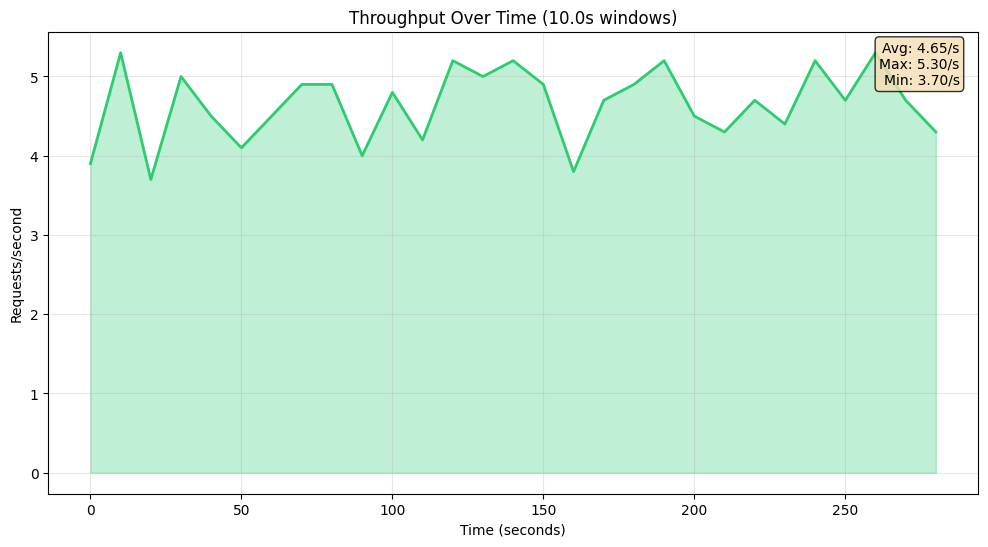

In [24]:
def add_stats_box(ax, text):
    ax.text(
        0.98, 0.98, text, transform=ax.transAxes, fontsize=10,
        verticalalignment="top", horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8)
    )

# 1. Throughput Over Time
fig, ax = plt.subplots()
ax.plot(stats["window_start"], stats["throughput_rps"], color="#2ecc71", linewidth=2)
ax.fill_between(stats["window_start"], stats["throughput_rps"], alpha=0.3, color="#2ecc71")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Requests/second")
ax.set_title(f"Throughput Over Time ({WINDOW_S}s windows)")

if not stats.empty and len(stats) > 0:
    stats_text = f"Avg: {stats['throughput_rps'].mean():.2f}/s\nMax: {stats['throughput_rps'].max():.2f}/s\nMin: {stats['throughput_rps'].min():.2f}/s"
    add_stats_box(ax, stats_text)
plt.show()


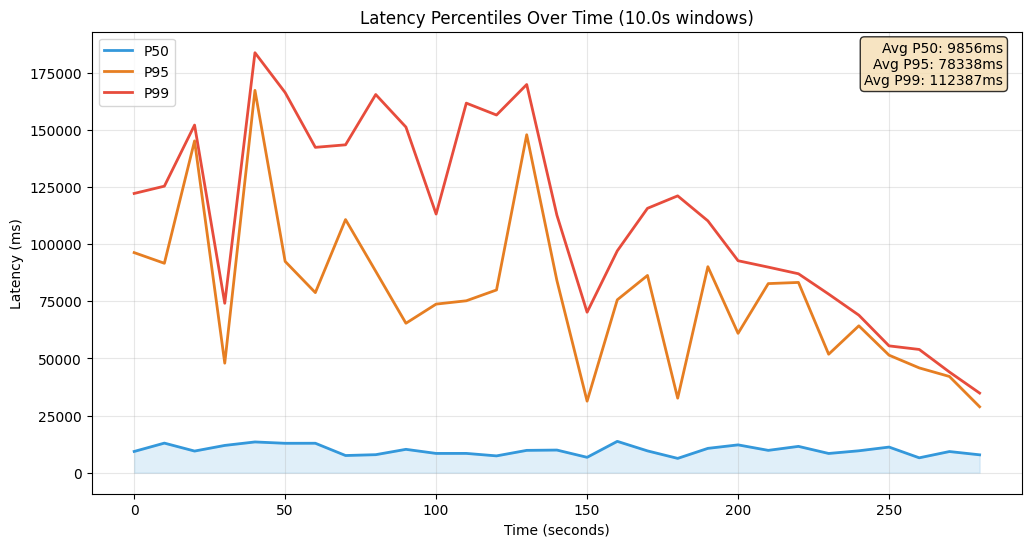

In [25]:
# 2. Latency Percentiles Over Time
fig, ax = plt.subplots()
ax.plot(stats["window_start"], stats["p50_ms"], color="#3498db", linewidth=2, label="P50")
ax.plot(stats["window_start"], stats["p95_ms"], color="#e67e22", linewidth=2, label="P95")
ax.plot(stats["window_start"], stats["p99_ms"], color="#e74c3c", linewidth=2, label="P99")
ax.fill_between(stats["window_start"], stats["p50_ms"], alpha=0.15, color="#3498db")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Latency (ms)")
ax.set_title(f"Latency Percentiles Over Time ({WINDOW_S}s windows)")
ax.legend(loc="upper left")

if not stats.empty and len(stats) > 0:
    stats_text = f"Avg P50: {stats['p50_ms'].mean():.0f}ms\nAvg P95: {stats['p95_ms'].mean():.0f}ms\nAvg P99: {stats['p99_ms'].mean():.0f}ms"
    add_stats_box(ax, stats_text)
plt.show()


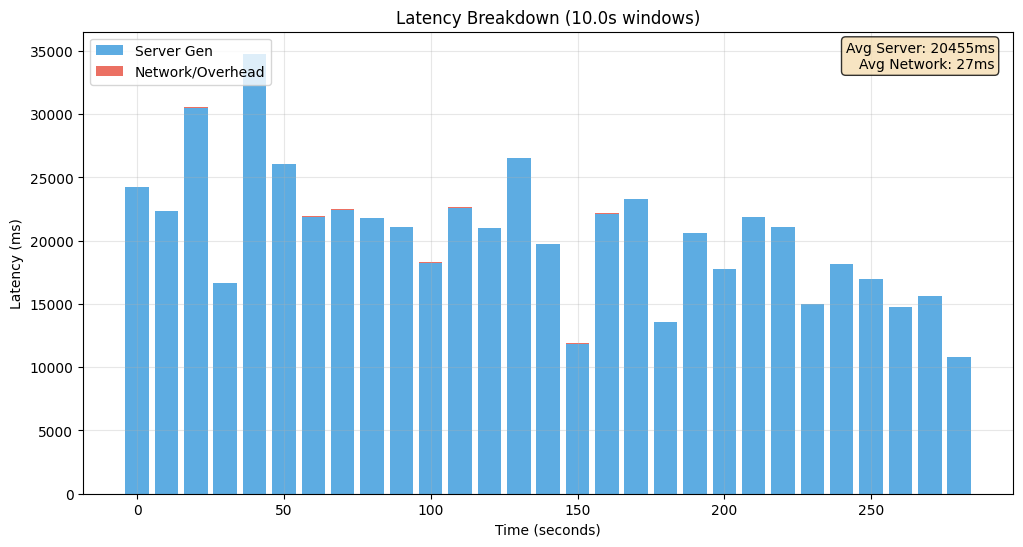

In [26]:
# 3. Server vs Network Latency Breakdown
if "avg_server_gen_ms" in stats.columns:
    s = stats.dropna(subset=["avg_server_gen_ms", "avg_network_ms"])
    if not s.empty:
        fig, ax = plt.subplots()
        ax.bar(s["window_start"], s["avg_server_gen_ms"], width=WINDOW_S * 0.8,
               color="#3498db", alpha=0.8, label="Server Gen")
        ax.bar(s["window_start"], s["avg_network_ms"], width=WINDOW_S * 0.8,
               bottom=s["avg_server_gen_ms"], color="#e74c3c", alpha=0.8, label="Network/Overhead")
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Latency (ms)")
        ax.set_title(f"Latency Breakdown ({WINDOW_S}s windows)")
        ax.legend(loc="upper left")

        stats_text = f"Avg Server: {s['avg_server_gen_ms'].mean():.0f}ms\nAvg Network: {s['avg_network_ms'].mean():.0f}ms"
        add_stats_box(ax, stats_text)
        plt.show()
    else:
        print("No server generation time data available to plot breakdown.")


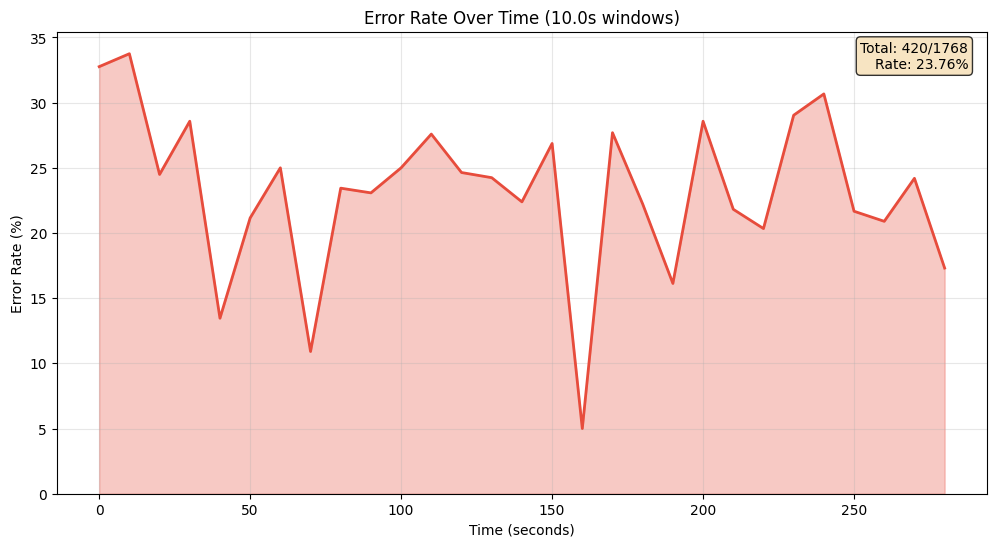

In [27]:
# 4. Error Rate Over Time
fig, ax = plt.subplots()
ax.plot(stats["window_start"], stats["error_rate"] * 100, color="#e74c3c", linewidth=2)
ax.fill_between(stats["window_start"], stats["error_rate"] * 100, alpha=0.3, color="#e74c3c")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Error Rate (%)")
ax.set_title(f"Error Rate Over Time ({WINDOW_S}s windows)")
ax.set_ylim(bottom=0)

total_errs = stats["server_errors"].sum() + stats["client_errors"].sum()
total_reqs = stats["requests"].sum()
rate = (total_errs / total_reqs * 100) if total_reqs > 0 else 0
stats_text = f"Total: {int(total_errs)}/{int(total_reqs)}\nRate: {rate:.2f}%"
add_stats_box(ax, stats_text)
plt.show()


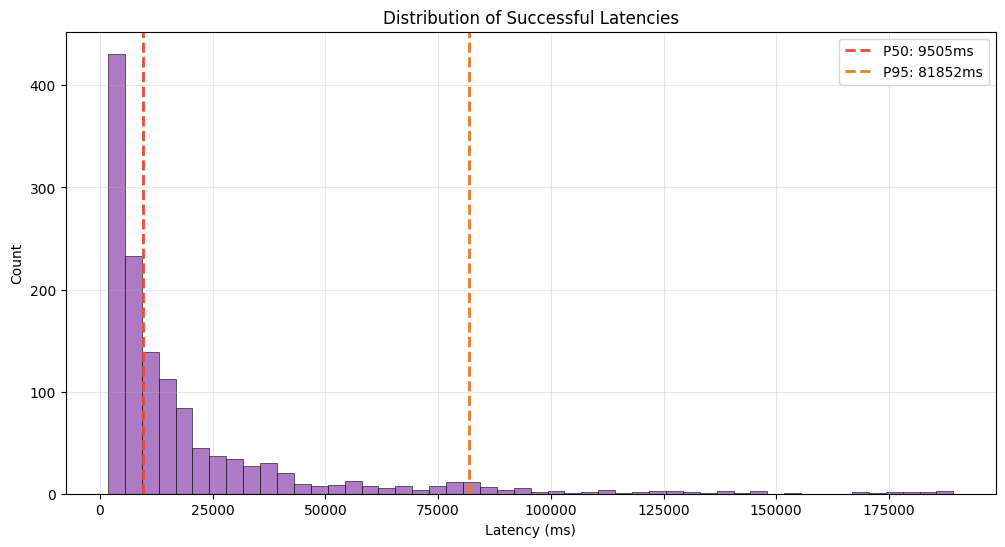

In [28]:
# 5. Latency Distribution Histogram
success_df = trimmed[trimmed["success"] == True]
if not success_df.empty:
    fig, ax = plt.subplots()
    latencies = success_df["latency_ms"]
    ax.hist(latencies, bins=50, color="#9b59b6", alpha=0.8, edgecolor="black", linewidth=0.5)
    
    p50 = latencies.median()
    p95 = latencies.quantile(0.95)
    ax.axvline(p50, color="#e74c3c", linewidth=2, linestyle="--", label=f"P50: {p50:.0f}ms")
    ax.axvline(p95, color="#e67e22", linewidth=2, linestyle="--", label=f"P95: {p95:.0f}ms")
    
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of Successful Latencies")
    ax.legend()
    plt.show()
else:
    print("No successful requests to plot latency distribution.")
